# TP de Synthèse : Machine Learning avec Python

L'objectif de ce TP est de faire une synthèse de toutes les notions que vous avez vu sur l'ensemble du cours IA & Python.

À partir d'un jeu de donnée imposé, vous allez devoir proposer une analyse détaillée, et produire des modèles prédictifs avec les meilleures performances possibles.

## À votre disposition :
- Un fichier `Hotel_Booking.csv` contenant les données à analyser, avec pour chaque donnée la valeur de la classe à prédire
- Un fichier `Data_Test.csv` de test, comprenant des données sans la valeur de la classe
- Ce notebook, contenant toutes vos instructions, ainsi qu'une description du _Dataset_

## Méthode de travail :
Ce travail peut-être effectué seul, ou en groupe de 2 personnes.

## Rendus attendus :
- Un notebook comprenant votre analyse détaillé du _Dataset_, et la construction de vos modèles prédictifs
- Un fichier CSV, avec sur chaque ligne votre prédiction de classe pour la ligne correspondante dans le fichier de test (`Donnees_Test.csv`).<br/>Ce fichier doit être nommé `NOM_Prénom.csv` ou `NOM1_NOM2.csv` (si binôme) ou `NOM_Prénom_vX.csv` (si plusieurs versions), et ne contient qu'une info par ligne : soit `Canceled`, soit `Not_Canceled`.

## Évaluation :
- Lorsque tous les groupes auront rendu leur fichier csv, le formatteur fera tourner un script, pour identifier le groupe ayant produit le modèle avec le meilleur résultat sur le jeu de test.
- Vous devrez fournir vos notebook à un autre groupe de la classe, et relire le notebook d'un autre groupe, pour lui faire un retour sur la qualité de l'analyse de ses données.

## Description des données

Les données à votre disposition décrivent les informations des clients de réservations de chambres d'hôtels.

L'objectif est de détermine, pour chaque client, s'il risque d'annuler sa réservation.

Vous avez à votre disposition les attributs suivants :

- `Booking_ID`: identifiant unique de chaque réservation
- `no_of_adults`: nombre d'adultes dans la réservation
- `no_of_children`: nombre d'enfants dans la réservation
- `no_of_weekend_nights`: nombre de nuits en weekend (samedi ou dimanche) incluses dans la réservation
- `no_of_week_nights`: nombre de nuits de semaine (lundi au vendredi) incluses dans la réservation
- `type_of_meal_plan`: choix de formule repas
- `required_car_parking_space` : indique une réservation de place de parking (0 : non, 1 : oui)
- `room_type_reserved`: type de chambre réservé
- `lead_time` : nombre de jours entre la date de réservation et la date d'arrivée
- `arrival_year` : année de la date d'arrivée
- `arrival_month`: mois de la date d'arrivée
- `arrival_date`: jour de la date d'arrivée
- `market_segment_type`: désignation du segment marketing
- `repeated_guest` : indique s'il s'agit d'un client fréquent (0 : non, 1 : oui)
- `no_of_previous_cancellations` : nombre d'annulation déjà faite par ce client sur d'autres réservations
- `no_of_previous_bookings_not_canceled`: nombre de réservations déjà faites sans annulations
- `avg_price_per_room`: prix moyen journalier de la réservation (en euros)
- `no_of_special_requests`: nombre total des requêtes spécifiques du client (étage, vue, ...)
- `booking_status` : indique si la réservation a été annulée ou non (=classe à prédire !)

## Les questions auxquelles vous devez répondre

Nous vous proposons ci-après une liste de questions à vous poser.
Il ne s'agit pas d'une obligation, ni d'une liste exhaustive, mais elles doivent vous permettre de vérifier un certains nombre de points de votre analyse.

_N.B. : N'oubliez pas de vous appuyer dès que possible sur des représentations graphiques parlantes, et sur des statistiques précises._

1. Combien d'attributs ?
1. Combien de données ?
1. Combien de classes ?
1. Quelle répartition entre les classes ?
1. Valeurs manquantes ?
1. Quelle répartition des valeurs sur chaque attribut ?
1. Quelle caractérisation de chaque attribut ?
1. Corrélation entre certains attributs ?
1. Nettoyage des données nécessaire ?
1. Transformation des données ?
1. Normalisation ?
1. Quelle(s) forme(s) d'apprentissage ?
1. Quels algorithmes privilégier ?
1. Quelles performances privilégier ?
1. Comment améliorer les performances initiales ?
1. Comment choisir les paramètres des algorithmes ?

## Considérations supplémentaires

Il vous est également demandé de réfléchir aux questions suivantes :
1. Quelle valeur ajoutée pourrait apporter vos analyses et votre algorithme aux hôtels ?
1. À quels aspects législatisf devriez-vous prendre garde ?
1. Votre algorithme pourrait-il être utilisé à mauvais escient ?

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


## Combien d'attributs ?

In [52]:
df = pd.read_csv('Hotel_Booking.csv',delimiter=';')
print("Nombre d'attributs : ", len(df.columns))

Nombre d'attributs :  19


## Combien de données ?

In [53]:
print("Nombre de données : ", len(df))

Nombre de données :  29999


## Combien de classes ?

In [28]:
classes_uniques = df['booking_status'].unique()
print(f"Les classes uniques (valeurs) de 'booking_status' sont : {classes_uniques}")

Les classes uniques (valeurs) de 'booking_status' sont : ['Not_Canceled' 'Canceled']


## Quelle répartition entre les classes ?

In [29]:
repartition_classes = df['booking_status'].value_counts()
print("Répartition des classes dans 'booking_status' :\n", repartition_classes)

Répartition des classes dans 'booking_status' :
 booking_status
Not_Canceled    20210
Canceled         9789
Name: count, dtype: int64


## Valeurs manquantes ?

In [54]:
# Vérification du nombre de valeurs manquantes par colonne
missing_values = df.isna().sum()

print("Valeurs manquantes par colonne :")
print(missing_values)

Valeurs manquantes par colonne :
Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


## Quelle répartition des valeurs sur chaque attribut ?


In [55]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,1.843295,0.105137,0.812660,2.201307,0.031068,85.194740,2017.820527,7.418747,15.595920,0.025534,0.022367,0.146438,103.496161,0.621754
std,0.519065,0.401527,0.870109,1.411846,0.173504,85.949683,0.383754,3.066836,8.739681,0.157744,0.361121,1.693216,35.012418,0.788084
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.750000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.500000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.120000,1.000000
max,4.000000,10.000000,6.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


- La grande majorité des réservations sont pour deux adultes.
- 75% des réservations n'incluent aucun enfant. Le maximum de 10 est une valeur extrême (outlier) qui pourrait nécessiter une vérification.
- Les séjours sont relativement courts le week-end (75% des cas ont 2 nuits ou moins)
- Les nuitées en semaine sont plus nombreuses que celles du week-end (Moyenne approx 2.2 vs 0.81).

## Quelle caractérisation de chaque attribut ?

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            29999 non-null  object 
 1   no_of_adults                          29999 non-null  int64  
 2   no_of_children                        29999 non-null  int64  
 3   no_of_weekend_nights                  29999 non-null  int64  
 4   no_of_week_nights                     29999 non-null  int64  
 5   type_of_meal_plan                     29999 non-null  object 
 6   required_car_parking_space            29999 non-null  int64  
 7   room_type_reserved                    29999 non-null  object 
 8   lead_time                             29999 non-null  int64  
 9   arrival_year                          29999 non-null  int64  
 10  arrival_month                         29999 non-null  int64  
 11  arrival_date   

## Corrélation entre certains attributs ?

<Axes: >

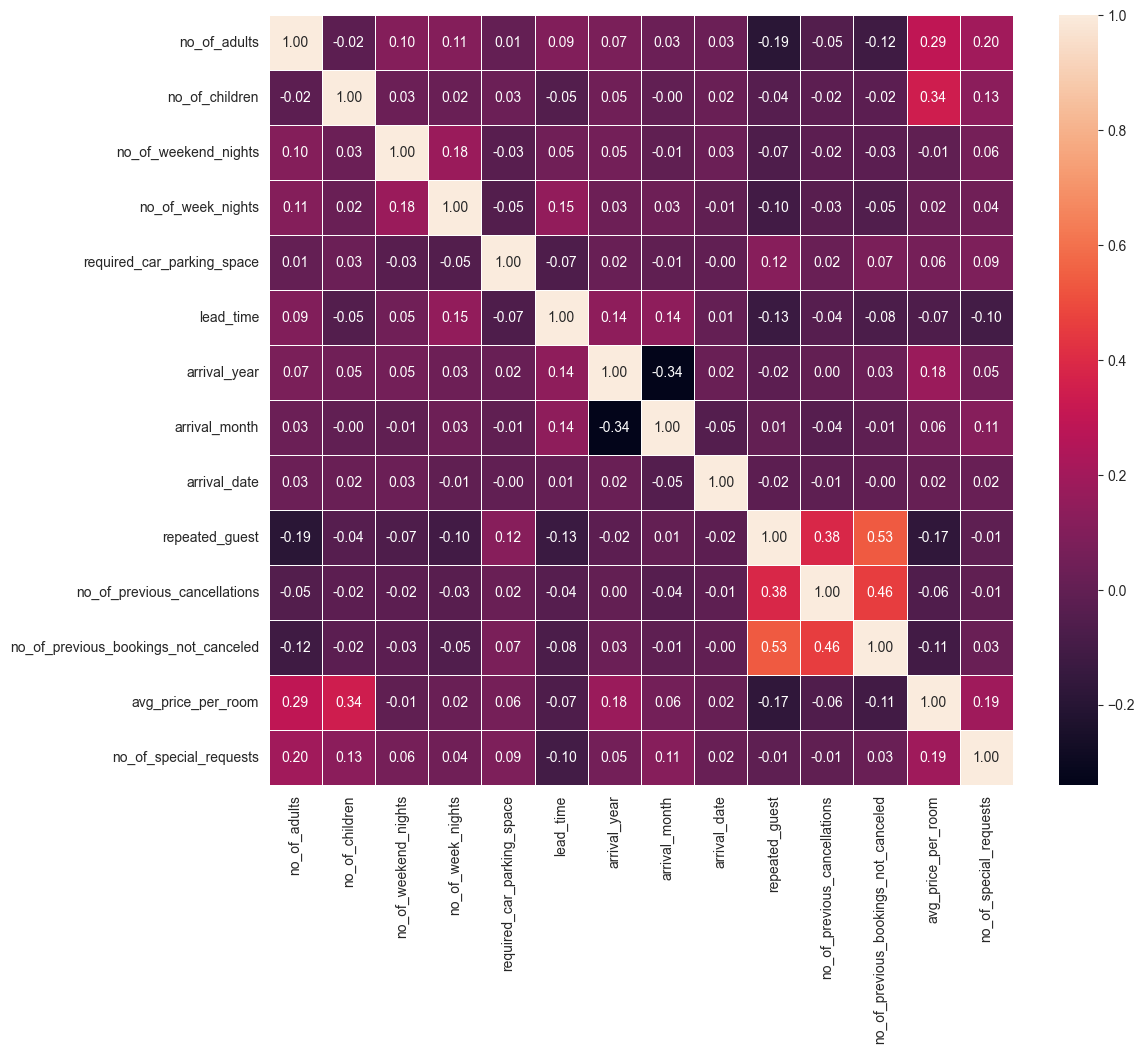

In [57]:
# 1. Sélection des colonnes numériques uniquement
numeric_df = df.select_dtypes(include='number')

# 2. Calcul des corrélations
correlation_matrix = numeric_df.corr()

# 3 Affichage de la heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",linewidths=.5, cbar=True)

## Nettoyage des données nécessaire ?

In [58]:
# Identifier et supprimer les lignes où le prix est égal à zéro
df = df[df['avg_price_per_room'] > 0]

# Supprimer les lignes où il n'y a ni adultes ni enfants (réservations vides)
df = df[ (df['no_of_adults'] + df['no_of_children']) > 0 ]

# Suppression de la colonne redondante
df.drop('no_of_previous_bookings_not_canceled', axis=1, inplace=True)

## Transformation des données ?

In [59]:
# Conversion de types pour l'optimisation
df['no_of_children'] = df['no_of_children'].astype('int64')
df['repeated_guest'] = df['repeated_guest'].astype('category')
df['required_car_parking_space'] = df['required_car_parking_space'].astype('category')

print("\n--- Aperçu du DataFrame après nettoyage ---")
print(f"Nouvelle taille du jeu de données : {df.shape}")
print(df.head())


--- Aperçu du DataFrame après nettoyage ---
Nouvelle taille du jeu de données : (29568, 18)
  Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
0  UID_00001             1               0                     1   
1  UID_00002             2               0                     2   
2  UID_00003             2               0                     0   
3  UID_00004             2               0                     2   
4  UID_00005             2               0                     0   

   no_of_week_nights type_of_meal_plan required_car_parking_space  \
0                  0       Meal Plan 1                          1   
1                  5       Meal Plan 1                          0   
2                  1       Meal Plan 1                          0   
3                  0       Meal Plan 2                          0   
4                  2       Meal Plan 2                          0   

  room_type_reserved  lead_time  arrival_year  arrival_month  arrival_date  \
0    

## Encodage

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29568 entries, 0 to 29998
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Booking_ID                    29568 non-null  object  
 1   no_of_adults                  29568 non-null  int64   
 2   no_of_children                29568 non-null  int64   
 3   no_of_weekend_nights          29568 non-null  int64   
 4   no_of_week_nights             29568 non-null  int64   
 5   type_of_meal_plan             29568 non-null  object  
 6   required_car_parking_space    29568 non-null  category
 7   room_type_reserved            29568 non-null  object  
 8   lead_time                     29568 non-null  int64   
 9   arrival_year                  29568 non-null  int64   
 10  arrival_month                 29568 non-null  int64   
 11  arrival_date                  29568 non-null  int64   
 12  market_segment_type           29568 non-null  objec

L'identification unique d'un passager n'est pas pertinent pour la prédiction, donc suppression de cette colonne

In [61]:
df.drop('Booking_ID', axis=1, inplace=True)

Encodage des données categorielle (object) pour utilisation par algorithmes
- type_of_meal_plan
- room_type_reserved
- market_segment_type
- booking_status

In [62]:
# --- 1. One-Hot Encoding pour les variables nominales ---
nominal_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

# Appliquer One-Hot Encoding
# 'drop_first=True' est souvent utilisé pour éviter la multicolinéarité
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# --- 2. Label Encoding pour la variable cible (Booking Status) ---
target_col = 'booking_status'

# Initialiser le LabelEncoder
le = LabelEncoder()

# Appliquer Label Encoding
df[target_col + '_encoded'] = le.fit_transform(df[target_col])

# Afficher les classes et leurs encodages correspondants
print(f"Classes de '{target_col}' et leurs valeurs encodées :")
for i, name in enumerate(le.classes_):
    print(f"  {name}: {i}")

# Supprimer la colonne de statut de réservation d'origine (object)
df = df.drop(columns=[target_col])

# Afficher les premières lignes du DataFrame après encodage
print("\nDataFrame après encodage (premières lignes) :")
print(df.head())

Classes de 'booking_status' et leurs valeurs encodées :
  Canceled: 0
  Not_Canceled: 1

DataFrame après encodage (premières lignes) :
   no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
0             1               0                     1                  0   
1             2               0                     2                  5   
2             2               0                     0                  1   
3             2               0                     2                  0   
4             2               0                     0                  2   

  required_car_parking_space  lead_time  arrival_year  arrival_month  \
0                          1         37          2018              3   
1                          0        138          2018              5   
2                          0          4          2018             11   
3                          0        386          2018             10   
4                          0        102         

Conversion en numerique des données categorielles (Category) pour utilisation algorithme
- required_car_parking_space
- repeated_guest

In [63]:
# Conversion des colonnes 'category' (supposées être 0/1) en int64
colonnes_a_convertir = ['required_car_parking_space', 'repeated_guest']

for col in colonnes_a_convertir:
    # On utilise .astype('int64') pour convertir directement la catégorie en entier
    # Cela fonctionne si les catégories sont déjà 0 et 1.
    df[col] = df[col].astype('int64')

# Afficher les types de données mis à jour pour vérification
print(df[colonnes_a_convertir].info())

<class 'pandas.core.frame.DataFrame'>
Index: 29568 entries, 0 to 29998
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   required_car_parking_space  29568 non-null  int64
 1   repeated_guest              29568 non-null  int64
dtypes: int64(2)
memory usage: 693.0 KB
None


Création d'une colonne de date complète
- arrival_year
- arrival_month
- arrival_date

In [64]:
df['Full_Date'] = pd.to_datetime(df[['arrival_year', 'arrival_month', 'arrival_date']].rename(
    columns={'arrival_year': 'year', 'arrival_month': 'month', 'arrival_date': 'day'}
))

ValueError: cannot assemble the datetimes: day 29 must be in range 1..28 for month 2 in year 2018, at position 512. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

## Normalisation ?

## Quelle(s) forme(s) d'apprentissage ?

## Quels algorithmes privilégier ?

## Quelles performances privilégier ?

## Comment améliorer les performances initiales ?

## Comment choisir les paramètres des algorithmes ?

## Quelle valeur ajoutée pourrait apporter vos analyses et votre algorithme aux hôtels ?

## À quels aspects législatisf devriez-vous prendre garde ?

## Votre algorithme pourrait-il être utilisé à mauvais escient ?